In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('data/youtube_channel_real_performance_analytics.csv')

In [4]:
df['Views'] = pd.to_numeric(df['Views'], errors='coerce').fillna(0)
df['Likes'] = pd.to_numeric(df['Likes'], errors='coerce').fillna(0)
df['New Comments'] = pd.to_numeric(df['New Comments'], errors='coerce').fillna(0)

In [5]:
df['engagement_rate'] = (df['Likes'] + df['New Comments']) / (df['Views'] + 1)

In [6]:
top_viewed = df[['ID', 'Views', 'Likes', 'engagement_rate']].sort_values(by='Views', ascending=False).head(5)
top_engaged = df[['ID', 'Views', 'Likes', 'engagement_rate']].sort_values(by='engagement_rate', ascending=False).head(5)

In [7]:
print("--- Top 5 Most Viewed Videos ---")
print(top_viewed)
print("\n--- Top 5 Most Engaging Videos ---")
print(top_engaged)

--- Top 5 Most Viewed Videos ---
      ID     Views    Likes  engagement_rate
228  228  670990.0  27222.0         0.042340
188  188  629864.0  20861.0         0.034172
142  142  562751.0  20908.0         0.039145
196  196  527343.0  13881.0         0.027166
108  108  485866.0  14102.0         0.034190

--- Top 5 Most Engaging Videos ---
      ID    Views   Likes  engagement_rate
79    79   4254.0   440.0         0.132080
320  320  82503.0  9672.0         0.130733
271  271  46865.0  5578.0         0.128345
66    66   4512.0   425.0         0.123200
274  274  58306.0  6306.0         0.113383


In [8]:
category_perf = df.groupby('Day of Week')[['Views', 'Likes', 'engagement_rate']].mean().sort_values(by='Views', ascending=False)

In [9]:
plt.figure(figsize=(16, 6))

<Figure size 1600x600 with 0 Axes>

<Figure size 1600x600 with 0 Axes>

C:\Users\Testing\AppData\Local\Temp\ipykernel_18124\2559210136.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_perf.index, y='Views', data=category_perf, palette='coolwarm')


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Friday'),
  Text(1, 0, 'Sunday'),
  Text(2, 0, 'Monday'),
  Text(3, 0, 'Wednesday'),
  Text(4, 0, 'Saturday'),
  Text(5, 0, 'Tuesday'),
  Text(6, 0, 'Thursday')])

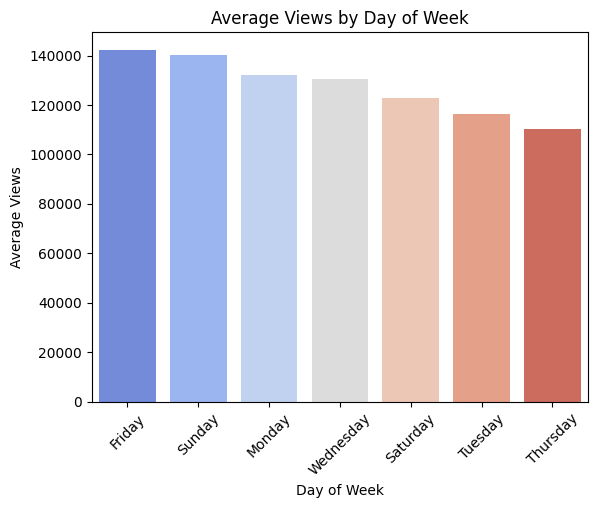

In [10]:
plt.subplot(1, 1, 1)
sns.barplot(x=category_perf.index, y='Views', data=category_perf, palette='coolwarm')
plt.title('Average Views by Day of Week')
plt.ylabel('Average Views')
plt.xticks(rotation=45)

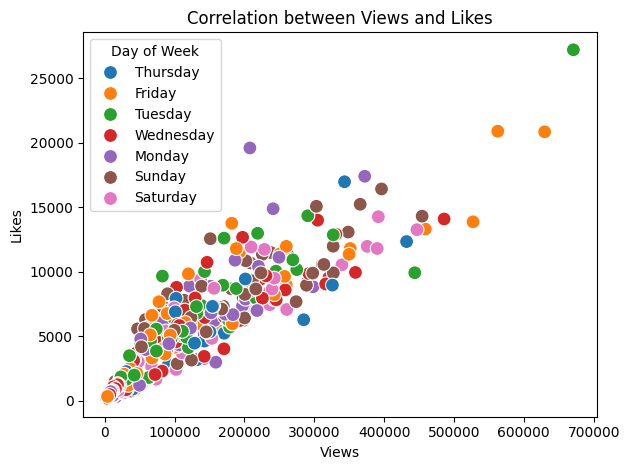

In [11]:
plt.subplot(1, 1,1)
sns.scatterplot(x='Views', y='Likes', hue='Day of Week', data=df, s=100)
plt.title('Correlation between Views and Likes')
plt.xlabel('Views')
plt.ylabel('Likes')

plt.tight_layout()
plt.show()

In [13]:
print("\nPERFORMANCE INSIGHTS ")
print(f"1. Most views are generated on: {category_perf.index[0]}")
print(f"2. Highest audience interaction occurs on: {category_perf['engagement_rate'].idxmax()}")
print(f"3. Maximum views recorded for a single video: {df['Views'].max():,.0f}")


PERFORMANCE INSIGHTS 
1. Most views are generated on: Friday
2. Highest audience interaction occurs on: Tuesday
3. Maximum views recorded for a single video: 670,990
